In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/ai4i2020.csv")

# Display first 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [10]:
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())


Duplicate rows: 0

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [11]:
failure_counts = df["Machine failure"].value_counts()

print("Machine failure counts:")
print(failure_counts)

print("\nFailure percentages:")
print(df["Machine failure"].value_counts(normalize=True) * 100)




Machine failure counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure percentages:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [12]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


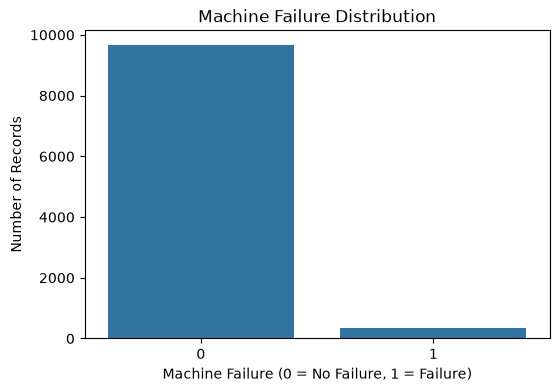

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Machine failure", data=df)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Records")

plt.show()


In [14]:
df.groupby("Machine failure")[features].mean().T

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


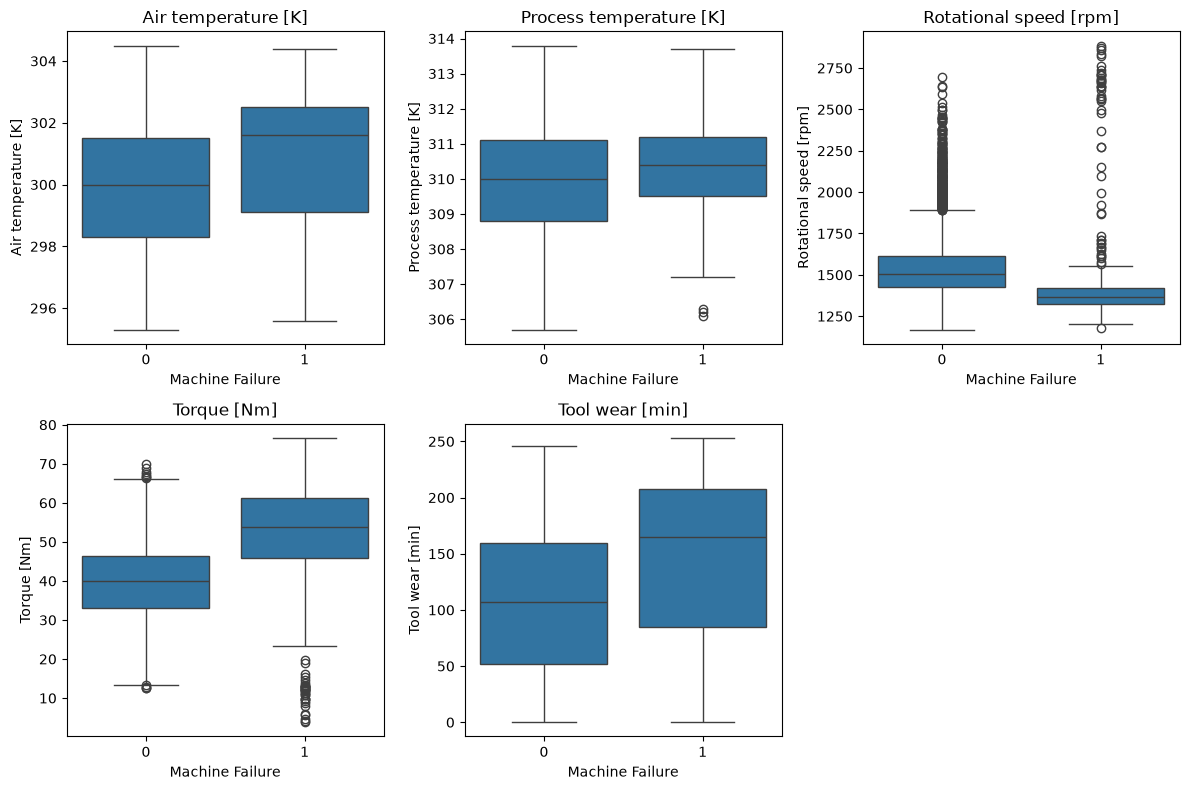

In [15]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    
    sns.boxplot(
        x="Machine failure",
        y=feature,
        data=df
    )
    
    plt.title(feature)
    plt.xlabel("Machine Failure")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [16]:
correlation = df[features + ["Machine failure"]].corr()

correlation["Machine failure"].sort_values(ascending=False)


Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

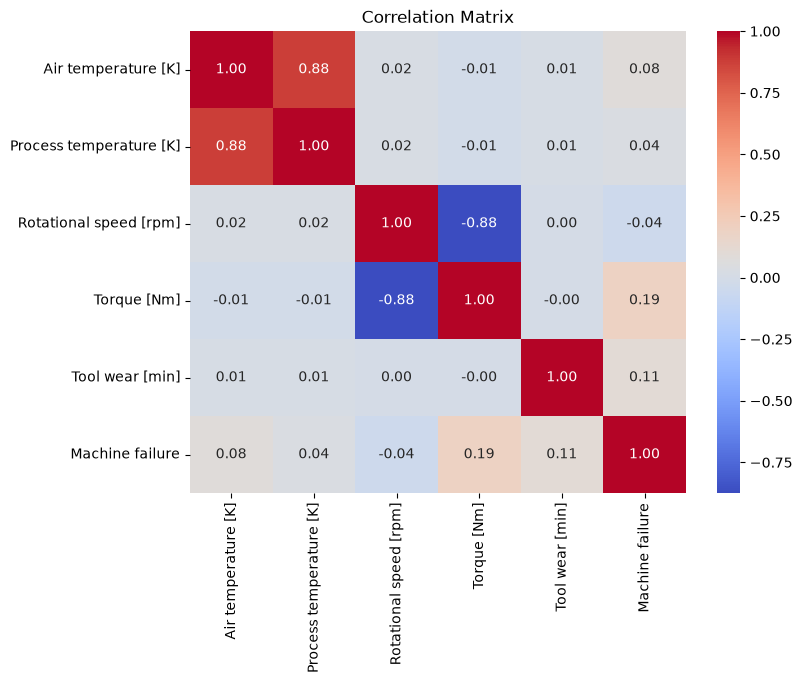

In [17]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [18]:
X = df[features]

y = df["Machine failure"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)



Features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure

X shape: (10000, 5)
y shape: (10000,)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Select input features
X = df[features]

# 2. Select target
y = df["Machine failure"]

# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (8000, 5)
Testing data: (2000, 5)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [20]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nFailure rate in training data:")
print(y_train.mean())

print("\nFailure rate in testing data:")
print(y_test.mean())

X_train: (8000, 5)
X_test : (2000, 5)
y_train: (8000,)
y_test : (2000,)

Failure rate in training data:
0.033875

Failure rate in testing data:
0.034


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

# Train and evaluate each model
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.9845,0.877551,0.632353,0.735043,0.965096
2,Random Forest,0.9815,0.731343,0.720588,0.725926,0.967783
1,Decision Tree,0.9755,0.679245,0.529412,0.595041,0.760306
0,Logistic Regression,0.8210,0.139303,0.823529,0.238298,0.908043


Logistic Regression
              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



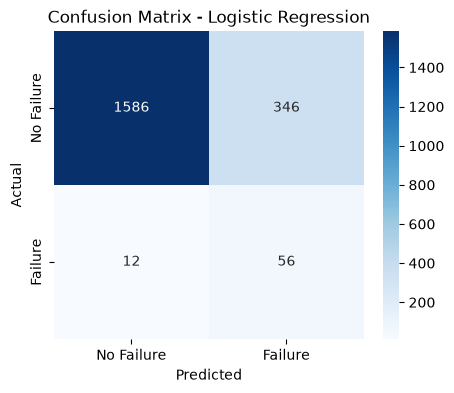

Decision Tree
              precision    recall  f1-score   support

  No Failure       0.98      0.99      0.99      1932
     Failure       0.68      0.53      0.60        68

    accuracy                           0.98      2000
   macro avg       0.83      0.76      0.79      2000
weighted avg       0.97      0.98      0.97      2000



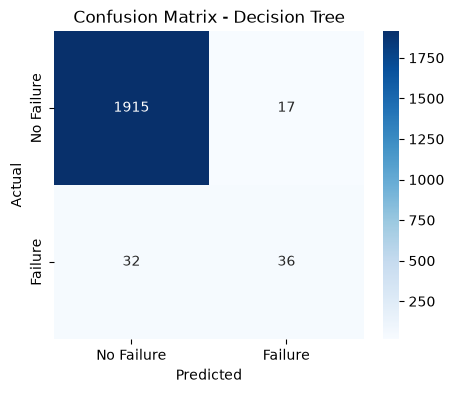

Random Forest
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.73      0.72      0.73        68

    accuracy                           0.98      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.98      0.98      0.98      2000



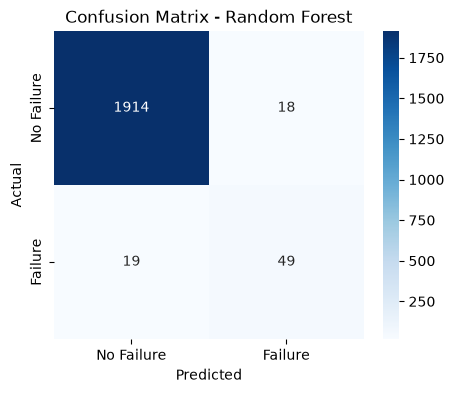

Gradient Boosting
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.88      0.63      0.74        68

    accuracy                           0.98      2000
   macro avg       0.93      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



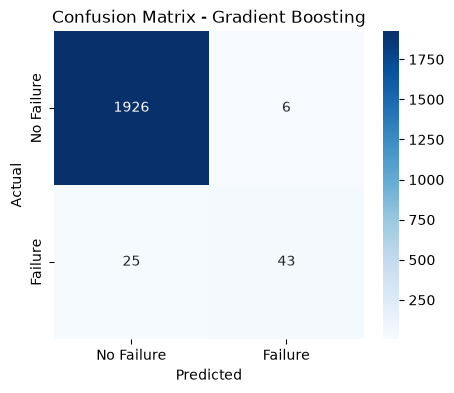

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Failure", "Failure"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Failure", "Failure"],
        yticklabels=["No Failure", "Failure"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

                   Feature  Importance
3              Torque [Nm]    0.328165
2   Rotational speed [rpm]    0.306219
4          Tool wear [min]    0.224945
0      Air temperature [K]    0.083586
1  Process temperature [K]    0.057085


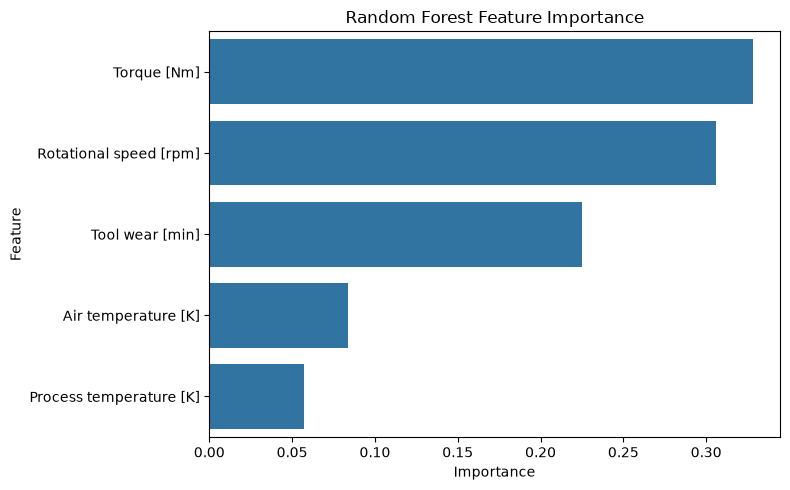

In [23]:
# Get the trained Random Forest model
rf_model = models["Random Forest"]

# Get feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

# Plot feature importance
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [24]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save Random Forest
joblib.dump(
    models["Random Forest"],
    "models/random_forest_model.pkl"
)

# Save Gradient Boosting
joblib.dump(
    models["Gradient Boosting"],
    "models/gradient_boosting_model.pkl"
)

print("Models saved successfully!")

Models saved successfully!


In [25]:
import joblib
import pandas as pd

# Load the saved model
model = joblib.load("models/random_forest_model.pkl")

# Example new machine sensor readings
new_machine = pd.DataFrame([{
    "Air temperature [K]": 300.0,
    "Process temperature [K]": 310.0,
    "Rotational speed [rpm]": 1500,
    "Torque [Nm]": 50.0,
    "Tool wear [min]": 140
}])

# Make prediction
prediction = model.predict(new_machine)[0]

# Get probability of failure
probability = model.predict_proba(new_machine)[0][1]

print("Prediction:", prediction)
print("Failure probability:", round(probability * 100, 2), "%")

if prediction == 1:
    print("Result: Machine Failure Risk Detected")
else:
    print("Result: Machine Operating Normally")

Prediction: 0
Failure probability: 0.5 %
Result: Machine Operating Normally


In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(random_search.best_score_, 4))

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best Cross-Validation F1 Score:
0.6753
